[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/03a_surrogate_data.ipynb)

# 03a — Surrogate data: the tilt sweep and the pattern it hides

**Purpose.** Build everything the surrogate learns from, and establish the one
structural fact that makes it cheap to build.

**Inputs.** The committed scenario (`data/external/scenario.json`), the cell
table in `configs/simulation.yaml`, and a CUDA GPU with the `rt` extra.

**Outputs.** `data/interim/tilt_sweep.npz` and
`data/interim/scene_features.npz`. Notebook 03b trains against both.

---

### Why this is minutes rather than hours

One transmitter's orientation cannot alter another transmitter's field. If that
holds through Sionna-RT's solver as well as through the physics, then moving
`tilt[cell i, band b]` moves only the slice `rsrp[b, i]`, and the
36-dimensional problem is **36 independent one-dimensional ones**.

Two things follow. Setting every cell of a band to the same tilt and solving
once harvests all twelve transmitters at that tilt, so a full sweep costs
*tilts* solves rather than *tilts × cells*. And the sweep is then not a sample
of the objective landscape but **the whole of it** on its tilt grid — which is
what lets notebook 03b score the surrogate against exact ground truth without
ever calling the ray tracer again.

Section 2 measures the claim before section 4 spends anything on it.

## 0. Environment

Run this section first, wherever you are.

**Locally** it walks up to the project root and makes it the working directory,
so the root-relative paths in the configs resolve the way they do for
`task surrogate:dataset` and the DVC pipeline. Nothing is installed.

**In Colab** it also clones the repository, puts it on `sys.path`, and installs
what Colab does not ship. Sionna-RT needs a CUDA GPU — select a GPU runtime
first, or the sweep will fail.

In [2]:
# --- Environment bootstrap -------------------------------------------------
# Identical in every notebook in this project.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
BRANCH = "main"
SUBDIR = ""  # the project root is the repository root

# (import name, pip name). Colab ships numpy, pandas, pyarrow, matplotlib and
# seaborn; these are the ones it does not. sionna-rt needs a CUDA runtime, so
# select a GPU runtime before running this notebook.
COLAB_PACKAGES = [
    ("hydra", "hydra-core"),
    ("sionna.rt", "sionna-rt"),
    ("ax", "ax-platform"),
]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    checkout = Path("/content") / Path(REPO_URL).stem
    if not checkout.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(checkout)],
            check=True,
        )
    root = checkout / SUBDIR if SUBDIR else checkout
    missing = [pip for mod, pip in COLAB_PACKAGES if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    # JupyterLab starts the kernel in notebooks/; walk up to the project root.
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))  # makes `import src` work without an editable install

# Extra Hydra overrides consumed by load_config() in section 1. Reading them
# from the environment lets a smoke run shrink the budget, or a Colab session
# repoint the paths, without editing the notebook.
CONFIG_OVERRIDES: list[str] = os.environ.get("BAND_TILT_OVERRIDES", "").split()

print(f"project root: {root}   colab: {IN_COLAB}")

project root: d:\Projects\band-tilt   colab: False


In [2]:
# --- Colab: data and artifacts (optional) ----------------------------------
# data/ is DVC-tracked and not part of the clone, so a fresh Colab runtime has
# no scenario to optimize against. Either run notebook 00 first, or mount Drive
# and point the config at a copy that already holds one. Drive also survives a
# runtime reset, which /content does not.
#
# from google.colab import drive
#
# drive.mount("/content/drive")
# PROJECT_ROOT = "/content/drive/MyDrive/band-tilt"
# CONFIG_OVERRIDES += [
#     f"simulation.output.manifest_file={PROJECT_ROOT}/data/external/scenario.json",
#     f"data.output.mdt_file={PROJECT_ROOT}/data/processed/mdt.parquet",
#     f"optim.output.dir={PROJECT_ROOT}/outputs/optim",
# ]

## 1. Setup

`load_config()` composes the same config Hydra gives `task surrogate:dataset`,
so the notebook and the pipeline stage cannot drift apart.

In [3]:
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from src.config import load_config
from src.optim.space import TiltSpace
from src.surrogate import dataset as surrogate_data
from src.utils.plotting import save_fig, setup_plotting

cfg = load_config(CONFIG_OVERRIDES)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/03a_surrogate"))

space = TiltSpace.from_config(cfg)
n_band = len(space.band_names)
print(f"tilt space: {space.n_dim} dimensions, {len(space.cells)} cells x {n_band} bands")
for index, band in enumerate(space.band_names):
    lower = space.lower[index::n_band].max()
    upper = space.upper[index::n_band].min()
    print(f"  {band}: [{lower:g}, {upper:g}] deg, baseline {space.baseline[index]:g}")

STEP_DEG = float(cfg.surrogate.sweep.step_deg)
print(f"\nsweep resolution: {STEP_DEG} deg")

tilt space: 36 dimensions, 12 cells x 3 bands
  b2600: [0, 16] deg, baseline 8
  b1800: [0, 14] deg, baseline 6
  b700: [0, 12] deg, baseline 4

sweep resolution: 0.5 deg


## 2. Does one cell's tilt move another cell's map?

The whole design rests on the answer, so it is measured rather than argued.
Physics says transmitters do not couple — but a solver that shares one
Monte-Carlo stream across transmitters could still let one cell's orientation
shift another cell's samples, and that would be invisible in any single map.

Two band-solves against the same scene, the same material draw and the same
solver seed, differing in exactly one cell's tilt. The untouched transmitters
must come back **bit-identical**.

In [4]:
report = surrogate_data.check_decomposition(cfg)

print(f"moved {report.moved_cell} on {report.band}")
print(f"  its own map moved by up to      {report.moved_max_abs_delta_db:8.3f} dB")
print(f"  every other transmitter moved by {report.max_abs_delta_db:8.3f} dB")
print(f"\ndecomposition holds: {report.holds}")

if not report.holds:
    raise RuntimeError(
        "Tilts do not decompose per transmitter on this solver, so one sweep cannot stand "
        "in for every cell and the per-slice surrogate design does not survive. Stop here "
        "and re-plan rather than spending the sweep."
    )

jitc_llvm_init(): LLVM API initialization failed ..


moved n0c0 on b2600
  its own map moved by up to        29.020 dB
  every other transmitter moved by    0.000 dB

decomposition holds: True


## 3. Scene channels

The geometry the model reads: depression angle from each mast to each tile,
line-of-sight fraction, the signed distance field, and per-tile heights. All of
them are functions of the perturbed scene and the mast positions alone, so they
are cast once here and every tilt the optimizer ever tries reads the same
arrays.

Caching them is also what keeps training free of Mitsuba — `los_fraction` casts
a ray per sub-tile point per mast, and nothing in notebook 03b should need a
ray tracer.

In [5]:
feature_path = surrogate_data.build_features(cfg, cfg.surrogate.output.feature_file)
features = surrogate_data.load_features(feature_path)

print(f"elevation_deg  {features.elevation_deg.shape}  "
      f"[{features.elevation_deg.min():.1f}, {features.elevation_deg.max():.1f}] deg")
print(f"los_fraction   {features.los_fraction.shape}  mean {features.los_fraction.mean():.3f}")
print(f"mean_sdf_m     {features.mean_sdf_m.shape}  "
      f"[{features.mean_sdf_m.min():.1f}, {features.mean_sdf_m.max():.1f}] m")
print(f"max_height_m   {features.max_height_m.shape}  max {features.max_height_m.max():.1f} m")

scene features: data\interim\scene_features.npz  (1.1 MB)
elevation_deg  (12, 61, 74)  [1.1, 70.7] deg
los_fraction   (12, 61, 74)  mean 0.097
mean_sdf_m     (61, 74)  [-35.5, 333.3] m
max_height_m   (61, 74)  max 98.2 m


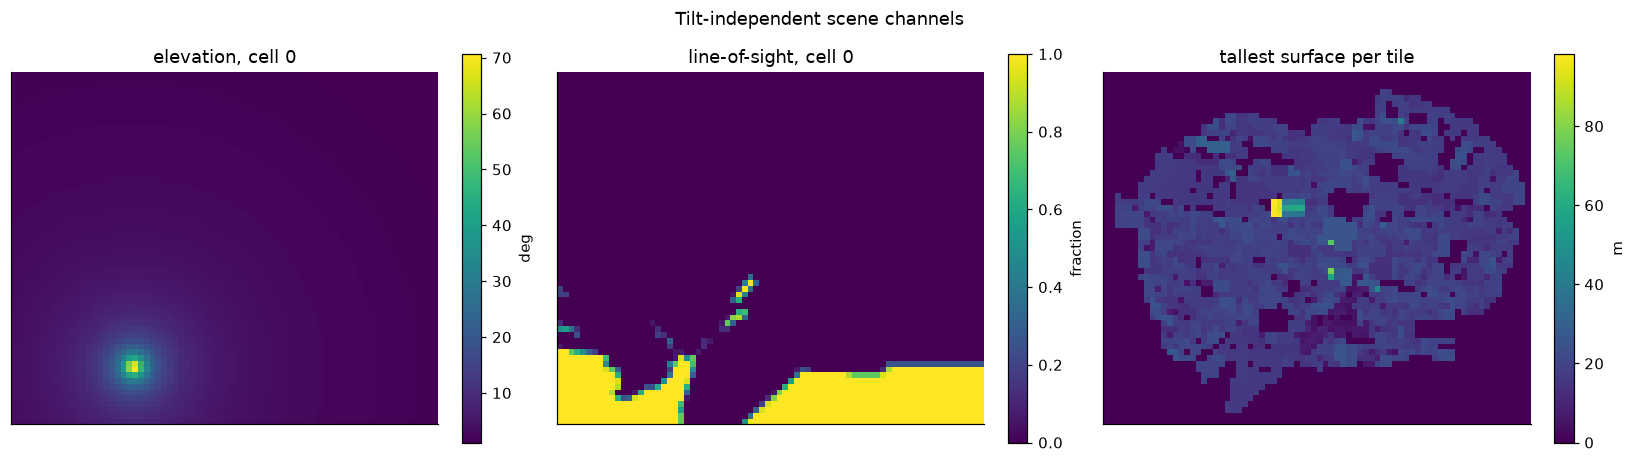

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (image, title, unit) in zip(
    axes,
    [
        (features.elevation_deg[0], "elevation, cell 0", "deg"),
        (features.los_fraction[0], "line-of-sight, cell 0", "fraction"),
        (features.max_height_m, "tallest surface per tile", "m"),
    ],
    strict=True,
):
    shown = ax.imshow(image, origin="lower", cmap="viridis")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(shown, ax=ax, label=unit, fraction=0.046)

fig.suptitle("Tilt-independent scene channels")
fig.tight_layout()
save_fig(fig, "scene_channels")

## 4. The sweep

Every band, over its whole tilt range, at `surrogate.sweep.step_deg`. Integer
degrees will train the model in 03b and the values between them will test it,
so the step has to divide one degree.

The first solve is timed and the projected total printed before the rest is
committed to — an unexpectedly slow machine should be visible in seconds, not
after an hour.

In [7]:
sweep_path = surrogate_data.sweep(cfg, STEP_DEG, cfg.surrogate.output.sweep_file)
sweep = surrogate_data.Sweep.load(sweep_path)

for band, name in enumerate(sweep.band_names):
    rsrp = sweep.rsrp[band]
    print(f"{name}: {rsrp.shape} [tilt, tx, row, col], "
          f"tilts {sweep.tilts[band][0]:g}..{sweep.tilts[band][-1]:g} deg, "
          f"finite {np.isfinite(rsrp).mean():.3f}")

tilt sweep: 87 band-solves over 3 bands
  first solve 4.4s -> projected 6.4 min
  b2600: (33, 12, 61, 74) [tilt, tx, row, col]
  b1800: (29, 12, 61, 74) [tilt, tx, row, col]
  b700: (25, 12, 61, 74) [tilt, tx, row, col]
tilt sweep: data\interim\tilt_sweep.npz  (6.1 MB, 87 solves)
b2600: (33, 12, 61, 74) [tilt, tx, row, col], tilts 0..16 deg, finite 0.341
b1800: (29, 12, 61, 74) [tilt, tx, row, col], tilts 0..14 deg, finite 0.339
b700: (25, 12, 61, 74) [tilt, tx, row, col], tilts 0..12 deg, finite 0.340


### What tilt actually does to coverage

Two views of the same table. The first is the fraction of tiles a transmitter
reaches at all as it tilts down — the thing the analytic model structurally
cannot predict, and the reason the operator carries a coverage head. The second
is RSRP against tilt for a handful of individual tiles, which is the
one-dimensional function the surrogate has to learn per dimension.

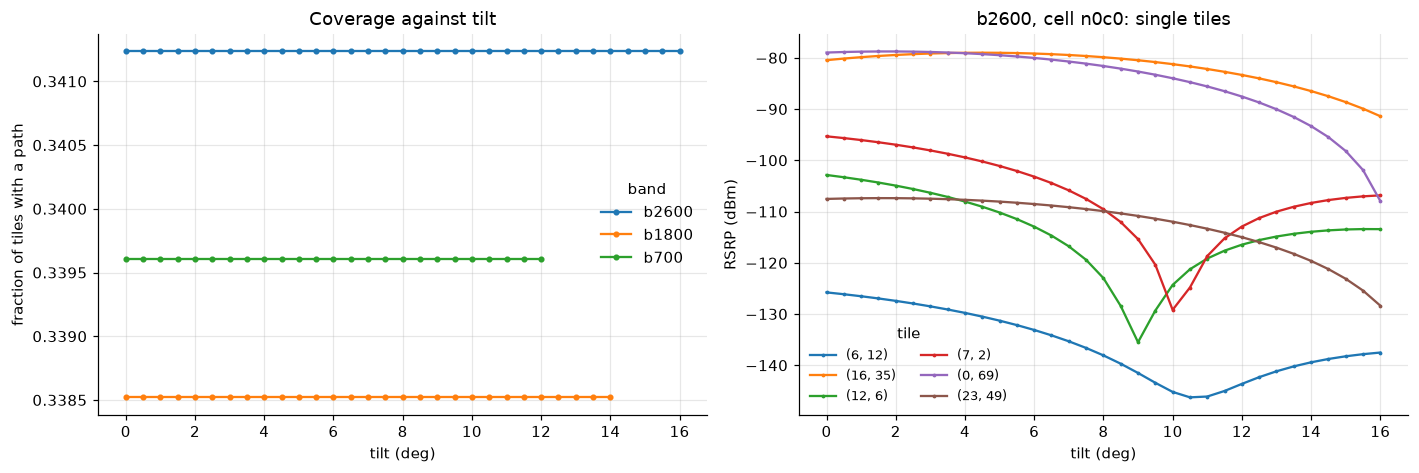

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

for band, name in enumerate(sweep.band_names):
    covered = np.isfinite(sweep.rsrp[band]).mean(axis=(1, 2, 3))
    axes[0].plot(sweep.tilts[band], covered, marker="o", markersize=3, label=name)
axes[0].set(xlabel="tilt (deg)", ylabel="fraction of tiles with a path",
            title="Coverage against tilt")
axes[0].legend(title="band")

rng = np.random.default_rng(0)
curves = sweep.rsrp[0][:, 0]
finite_everywhere = np.isfinite(curves).all(axis=0)
rows, cols = np.nonzero(finite_everywhere)
for pick in rng.choice(len(rows), size=min(6, len(rows)), replace=False):
    row, col = rows[pick], cols[pick]
    axes[1].plot(sweep.tilts[0], curves[:, row, col], marker=".", markersize=3,
                 label=f"({row}, {col})")
axes[1].set(xlabel="tilt (deg)", ylabel="RSRP (dBm)",
            title=f"{sweep.band_names[0]}, cell {sweep.tx_names[0]}: single tiles")
axes[1].legend(title="tile", fontsize="small", ncols=2)

fig.tight_layout()
save_fig(fig, "tilt_response")

## 5. The pattern hiding in the sweep

For a path set that tilt only re-weights, RSRP separates:

$$\mathrm{RSRP}(t, p) = \underbrace{\mathrm{base}(p)}_{\text{tilt-independent}}
  + \underbrace{A\big(\mathrm{elev}(p) - t\big)}_{\text{pattern}}$$

Everything about geometry, material and the *horizontal* pattern is the same at
every tilt and lands in `base`; tilt enters only through the angle off
boresight. So the surrogate's job is not to learn propagation — it is to learn
where this separation **fails**.

`fit_pattern` recovers $A$ by differencing along tilt, which cancels `base`
outright and leaves the pattern's own first difference. That is exact and needs
no iteration. It is also deliberately *measured* rather than assumed: the 3GPP
TR 38.901 element pattern is not what an 8×8 cross-polarised array synthesises
under `RadioMapSolver`, and a surrogate built on that assumption would spend
its capacity unlearning the difference.

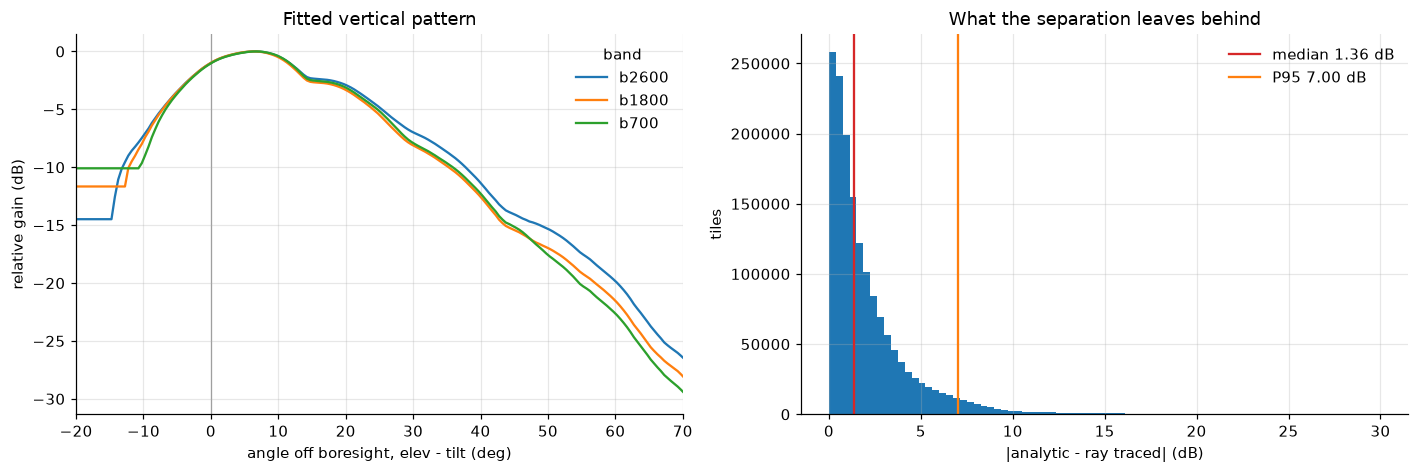

In [9]:
pattern = surrogate_data.fit_pattern(sweep, features.elevation_deg)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

for band, name in enumerate(pattern.band_names):
    axes[0].plot(pattern.offset_deg, pattern.gain_db[band], label=name)
axes[0].set(xlabel="angle off boresight, elev - tilt (deg)", ylabel="relative gain (dB)",
            title="Fitted vertical pattern", xlim=(-20, 70))
axes[0].legend(title="band")
axes[0].axvline(0.0, color="0.6", linewidth=0.8, zorder=0)

# How well the separation holds is the residual the operator has to learn.
errors = []
for band in range(len(sweep.band_names)):
    for index, tilt in enumerate(sweep.tilts[band]):
        actual = sweep.rsrp[band][index]
        finite = np.isfinite(actual)
        predicted = pattern.reference(band, features.elevation_deg, float(tilt))
        errors.append(np.abs(predicted[finite] - actual[finite]))
residual = np.concatenate(errors)

axes[1].hist(residual, bins=80, range=(0, 30), color="C0")
axes[1].set(xlabel="|analytic - ray traced| (dB)", ylabel="tiles",
            title="What the separation leaves behind")
axes[1].axvline(np.median(residual), color="C3",
                label=f"median {np.median(residual):.2f} dB")
axes[1].axvline(np.percentile(residual, 95), color="C1",
                label=f"P95 {np.percentile(residual, 95):.2f} dB")
axes[1].legend()

fig.tight_layout()
save_fig(fig, "fitted_pattern")

## 6. The training pairs

A pair is one training example: the map at one tilt, the scene, both tilts, and
the map at the other tilt as the target.

The split is on the **tilt axis, not the scene**. The scene is fixed by design
here, so the only generalisation that means anything is to tilts the ray tracer
never solved. Training pairs move between whole degrees; test pairs start on a
whole degree — as deployment always does, anchored on the committed tilts — and
land between them.

In [10]:
train_pairs = surrogate_data.TiltPairs(sweep, features, pattern, space.cells, "train")
test_pairs = surrogate_data.TiltPairs(sweep, features, pattern, space.cells, "test")

print(f"train {len(train_pairs):>6} pairs   (whole degree -> whole degree)")
print(f"test  {len(test_pairs):>6} pairs   (whole degree -> half degree)")

item = train_pairs[0]
print(f"\ninput stack {tuple(item['x'].shape)}:")
for index, name in enumerate(surrogate_data.TiltPairs.channels):
    channel = item["x"][index]
    print(f"  {index}  {name:<13} [{channel.min():7.3f}, {channel.max():7.3f}]")
print(f"\nconditioning {tuple(item['cond'].shape)}  angle maps {tuple(item['cond_map'].shape)}")

train   7656 pairs   (whole degree -> whole degree)
test    7656 pairs   (whole degree -> half degree)

input stack (10, 61, 74):
  0  rsrp_before   [ -4.552,   1.830]
  1  has_path      [  0.000,   1.000]
  2  delta_gain    [ -0.029,   0.069]
  3  elevation     [  0.025,   1.570]
  4  los_fraction  [  0.000,   1.000]
  5  sdf           [ -0.355,   3.333]
  6  max_height    [  0.000,   3.275]
  7  cos_bearing   [ -1.000,   1.000]
  8  sin_bearing   [ -1.000,   1.000]
  9  log_distance  [  0.333,   1.054]

conditioning (6,)  angle maps (2, 61, 74)


## 7. Handover to 03b

Both artifacts are on disk and DVC-tracked. Notebook 03b reads them, re-fits the
pattern from the same sweep, and trains the operator.

Nothing here learned anything: the pattern fit is a closed-form estimate, not a
model, and it is recomputed from the sweep wherever it is needed rather than
carried around as a fitted artifact of its own.

In [11]:
for path in (Path(cfg.surrogate.output.sweep_file), Path(cfg.surrogate.output.feature_file)):
    print(f"{path}  {path.stat().st_size / 1e6:6.1f} MB")

print(f"\nground truth is now free: sweep.at(tilt_vector) returns the exact map for any of the")
print(f"{np.prod([len(t) for t in sweep.tilts]):,.0f} ** {len(space.cells)} tilt vectors on this grid.")

data\interim\tilt_sweep.npz     6.1 MB
data\interim\scene_features.npz     1.1 MB

ground truth is now free: sweep.at(tilt_vector) returns the exact map for any of the
23,925 ** 12 tilt vectors on this grid.
